In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
import allanself
import scipy
import glob


# Data Processing and PLotting

In [11]:
def process_data(data_txt):
    # Read data
    cols = ['MJD', 'dX', 'sigma_dX', 'dY', 'sigma_dY']
    cols_widths = [(0,11),(12,22),(23,33),(34,44),(45,55)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=1, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna() 

    return df_new

In [12]:
files = glob.glob('nut_*.dat')

In [13]:
files

['nut_aus.dat',
 'nut_bkg.dat',
 'nut_c04.dat',
 'nut_gsfc.dat',
 'nut_iaa.dat',
 'nut_ivs.dat',
 'nut_opa.dat',
 'nut_usno.dat']

In [16]:
dfs = {}

for file in files:
    method_name = file.split('_')[1].split('.')[0]
    df = process_data(file)
    dfs[method_name] = df

In [20]:
dfs['aus'].head(5)

,MJD,dX,sigma_dX,dY,sigma_dY
0,47904.262,0.390,0.109,-0.321,0.109
1,47909.252,0.216,0.124,0.032,0.120
2,47914.252,0.321,0.129,-0.572,0.121
3,47919.250,0.597,0.119,-0.295,0.107
4,47924.248,0.022,0.162,0.078,0.206


<Figure size 1500x800 with 0 Axes>

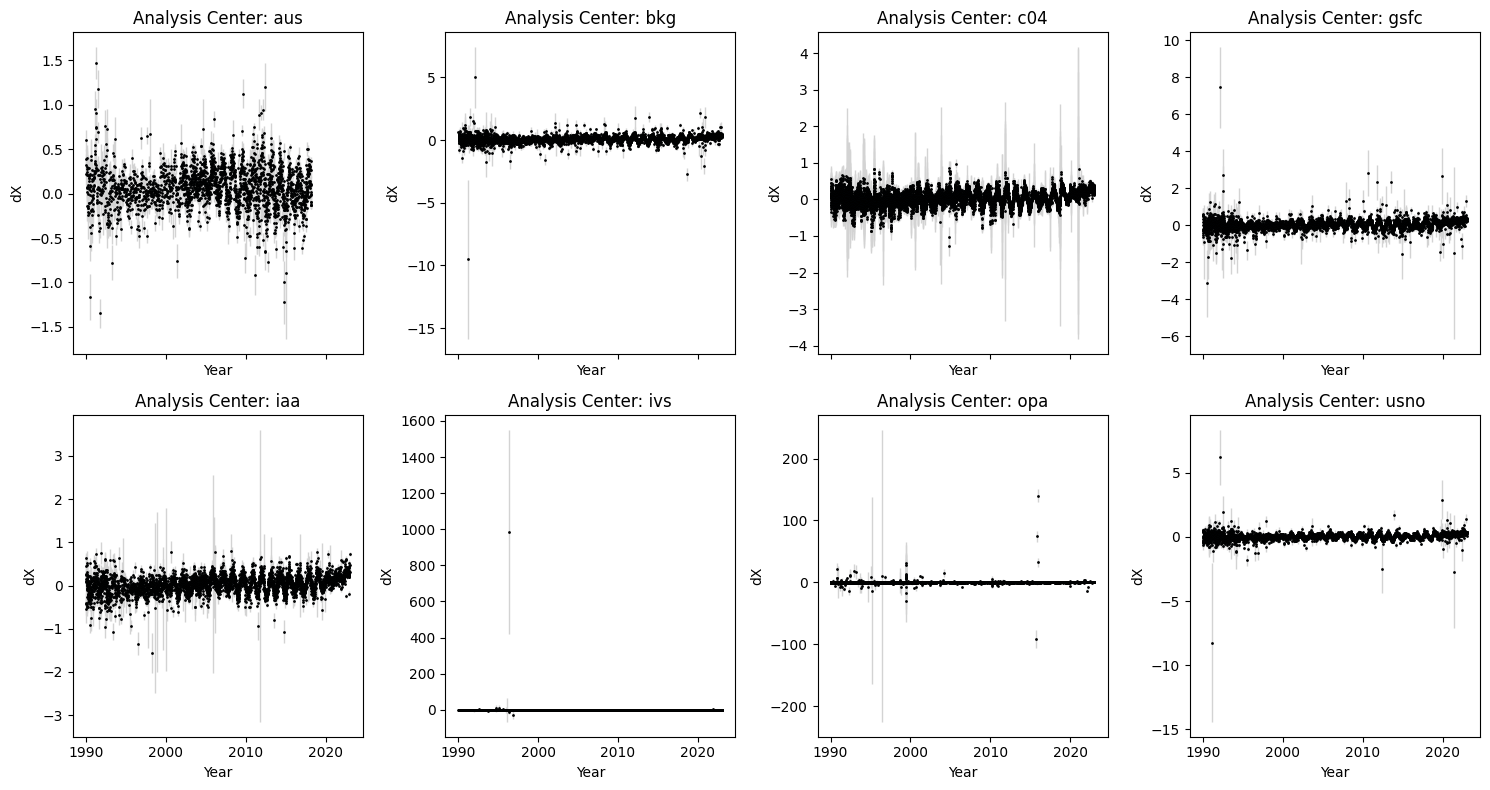

In [50]:
# Figure dX data plot for all methods
plt.figure(figsize=(15, 8))
plt.subplots_adjust(hspace=0.2)

# Create subplots
ncols = 4
nrows = len(dfs) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), sharex=True)
axes = axes.flatten()

# Iterate through each method in the dict
for i, (method, df) in enumerate(dfs.items()):
    # Plot with BY converted from MJD
    axes[i].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dX'], yerr=df['sigma_dX'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 

    axes[i].set_title(f'Analysis Center: {method}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('dX')

plt.tight_layout()
plt.show()

<Figure size 1500x800 with 0 Axes>

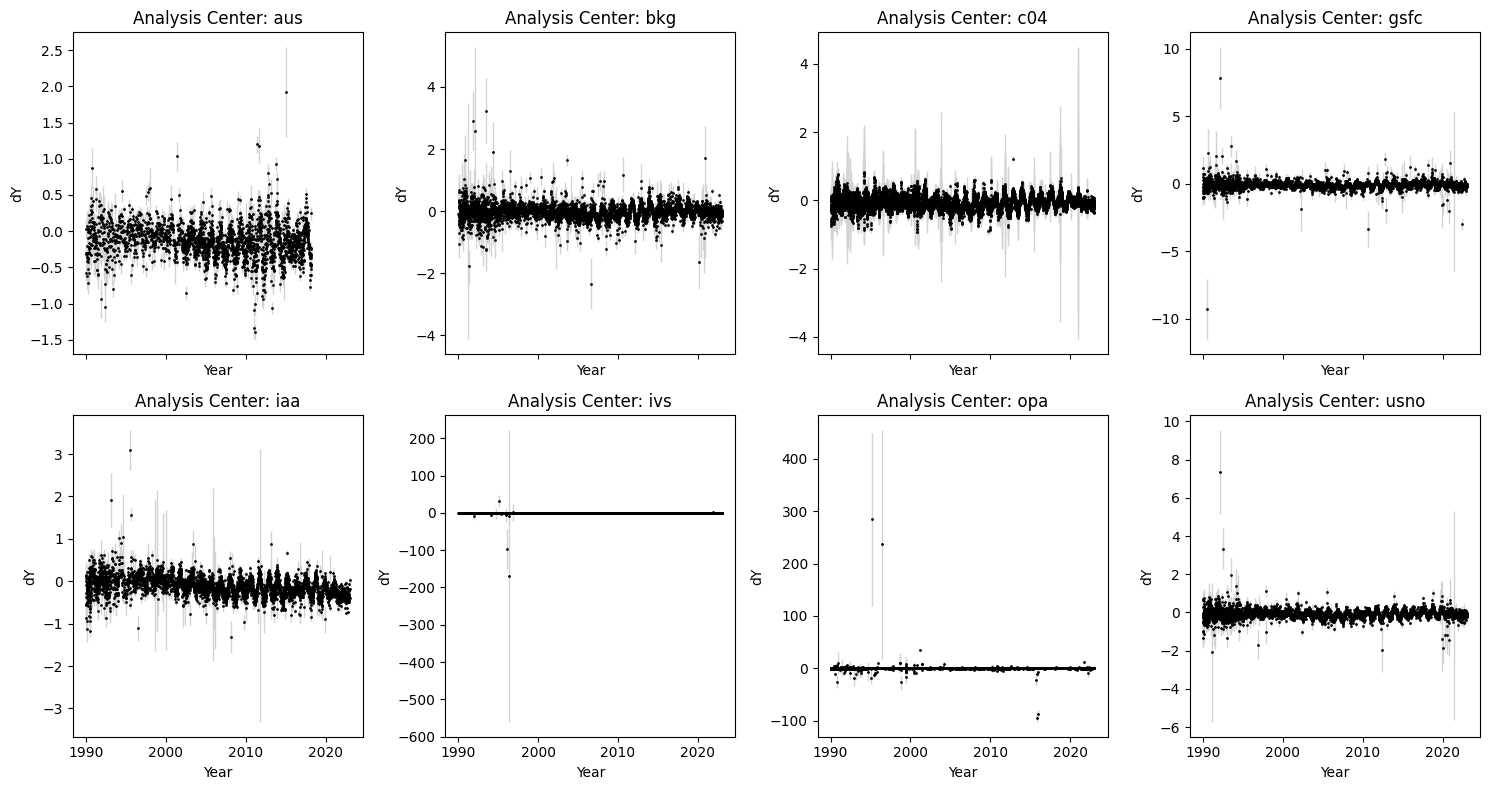

In [51]:
# Figure dX data plot for all methods
plt.figure(figsize=(15, 8))
plt.subplots_adjust(hspace=0.2)

# Create subplots
ncols = 4
nrows = len(dfs) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 8), sharex=True)
axes = axes.flatten()

# Iterate through each method in the dict
for i, (method, df) in enumerate(dfs.items()):
    # Plot with BY converted from MJD
    axes[i].errorbar(2000 - (51544.333981 - df['MJD']) / 365.242198781, df['dY'], yerr=df['sigma_dY'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1) 

    axes[i].set_title(f'Analysis Center: {method}')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel('dY')

plt.tight_layout()
plt.show()

# Allan - dX

In [52]:
allanstds_dX = {}  

for method, df in dfs.items():
    # Calculate allan std dev
    tau, allanstd = allanself.oadev(df['dX'].values,df['MJD'].values,df['sigma_dX'].values)

    allanstds_dX[method] = {'tau': tau, 'allanstd': allanstd}

c:\Users\Davendra\OneDrive - UNIVERSITAS INDONESIA\Documents\College\Academic\Research\MBKM\radio-sources\radio-sources\Nutation\allanself.py:393: RuntimeWarning: invalid value encountered in scalar divide
  allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))


In [53]:
allanstds_dX

{'aus': {'tau': [13.382346470333474,
   17.843128627111298,
   22.303910783889123,
   26.764692940666947,
   31.22547509744477,
   35.686257254222596,
   40.14703941100042,
   44.607821567778245,
   49.06860372455607,
   53.529385881333894,
   57.99016803811172,
   62.45095019488954,
   66.91173235166737,
   71.37251450844519,
   75.83329666522302,
   80.29407882200084,
   84.75486097877867,
   89.21564313555649,
   93.67642529233432,
   98.13720744911214,
   102.59798960588996,
   107.05877176266779,
   111.51955391944561,
   115.98033607622344,
   120.44111823300126,
   124.90190038977909,
   129.36268254655693,
   133.82346470333474,
   138.28424686011255,
   142.74502901689038,
   147.20581117366822,
   151.66659333044603,
   156.12737548722384,
   160.58815764400168,
   165.04893980077952,
   169.50972195755733,
   173.97050411433514,
   178.43128627111298,
   182.89206842789082,
   187.35285058466863,
   191.81363274144644,
   196.27441489822428,
   200.73519705500212,
   205.195

In [55]:
for method, result in allanstds_dX.items():
    filename = f"{method}_allanstd.txt"
    np.savetxt(filename, np.column_stack((result['tau'], result['allanstd'])), header="Tau Allanstd", comments="", delimiter='\t')